# Exploratory Data Analysis

## Setup

Imports and shared chart style constants (colour ramp, chart surface, text/grid colours) used by every figure in this notebook.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)


def show_full_numbers(ax, axis='x'):
    """Replace matplotlib's default 1e6-style offset notation with plain,
    comma-separated numbers (e.g. 1,000,000 instead of 1e6)."""
    formatter = mticker.FuncFormatter(lambda val, _: f"{val:,.0f}")
    (ax.xaxis if axis == 'x' else ax.yaxis).set_major_formatter(formatter)


# Ordinal one-hue ramp (blue, monotone lightness): bin order carries meaning
# (age bands, facility tiers), so color encodes that order, not identity.
ORDINAL_RAMP = ['#86b6ef', '#3987e5', '#1c5cab', '#0d366b']
CHART_SURFACE = '#fcfcfb'
TEXT_PRIMARY = '#0b0b0b'
TEXT_MUTED = '#898781'
GRIDLINE = '#e1e0d9'
BASELINE = '#c3c2b7'
ANOMALY_COLOR = '#eb6834'   # accent (categorical slot 2, orange) for flagged points


def eta_squared(data, group_col, value_col):
    """Proportion of variance in value_col explained by group membership in
    group_col - the categorical-variable equivalent of R-squared. Used
    because Pearson r cannot be computed for a nominal category like
    Property Type or State (there is no numeric ordering to correlate)."""
    grand_mean = data[value_col].mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2
                      for _, g in data.groupby(group_col)[value_col])
    ss_total = ((data[value_col] - grand_mean) ** 2).sum()
    return ss_between / ss_total


### Helper: `plot_ordinal_line_trend`

Line chart for a full ordered sequence (age/facility count), with an actual + smoothed line and optional median-bracket/range-band annotations.

In [2]:
def plot_ordinal_line_trend(labels, values, title, xlabel, ylabel, filename, smooth_window=5,
                             median_bracket=None, range_band=None, show_smoothed=True,
                             markers=False, label_rotation=None):
    """Line chart for a full ordered/ranked sequence (every raw value, not binned).
    By default the raw line is thin/faint (real but noisy) and a rolling-mean
    line on top carries the actual trend shape - this suits a variable with
    many points (e.g. every year of Property Age, every Facility Count).

    show_smoothed=False switches to a single line with no rolling-mean overlay,
    for a short ranked sequence (few categories, e.g. States) where a 5-point
    average isn't meaningful. markers=True adds a visible dot per point, useful
    when there are few enough points that each one matters individually.
    label_rotation overrides the default x-tick rotation (0 for <=20 labels,
    90 otherwise) - useful for a handful of long text labels.

    median_bracket: optional (label, y_value, text, side) - a dot + label at
    one representative point for a group's median. The line is allowed to
    pass behind the label (opaque background keeps the number readable).
    range_band: optional (label_start, label_end, y_low, y_high, text) -
    two dashed reference lines + one label for a plateau range."""
    n = len(labels)
    raw_color = ORDINAL_RAMP[1]
    smooth_color = ORDINAL_RAMP[-1]
    marker_style = 'o' if markers else None

    fig, ax = plt.subplots(figsize=(9, 5.5))
    fig.patch.set_facecolor(CHART_SURFACE)
    ax.set_facecolor(CHART_SURFACE)

    x = np.arange(n)

    if show_smoothed:
        smoothed = pd.Series(values).rolling(smooth_window, center=True, min_periods=1).mean()
        ax.fill_between(x, smoothed, 0, color=smooth_color, alpha=0.08, zorder=1)
        ax.plot(x, values, color=raw_color, linewidth=1.2, alpha=0.45, zorder=2, label="Actual",
                marker=marker_style, markersize=5)
        ax.plot(x, smoothed, color=smooth_color, linewidth=2.5, solid_capstyle='round',
                solid_joinstyle='round', zorder=3, label=f"Smoothed ({smooth_window}-point avg)")
    else:
        ax.fill_between(x, values, 0, color=smooth_color, alpha=0.08, zorder=1)
        ax.plot(x, values, color=smooth_color, linewidth=2.5, solid_capstyle='round',
                solid_joinstyle='round', zorder=3, marker=marker_style, markersize=8,
                markerfacecolor=CHART_SURFACE, markeredgecolor=smooth_color, markeredgewidth=2)

    label_box = dict(facecolor=CHART_SURFACE, edgecolor='none', pad=2)

    if median_bracket:
        label, y_value, text, side = median_bracket
        xi = labels.index(label)
        ax.scatter(xi, y_value, s=130, color=ORDINAL_RAMP[0], edgecolor=CHART_SURFACE,
                    linewidth=2, zorder=5)
        offset = max(values) * 0.03 * (1 if side == 'above' else -1)
        ax.text(xi, y_value + offset, text, ha='left', va='bottom' if side == 'above' else 'top',
                 fontsize=10, color=TEXT_PRIMARY, zorder=5, bbox=label_box)

    if range_band:
        label_start, label_end, y_low, y_high, text = range_band
        xi_start, xi_end = labels.index(label_start), labels.index(label_end)
        for y in (y_low, y_high):
            ax.hlines(y, xi_start, xi_end, color=TEXT_MUTED, linewidth=1.2,
                       linestyle=(0, (5, 3)), zorder=4)
        ax.text((xi_start + xi_end) / 2, y_high + max(values) * 0.03, text, ha='center', va='bottom',
                 fontsize=10, color=TEXT_PRIMARY, zorder=5, bbox=label_box)

    ax.yaxis.grid(True, color=GRIDLINE, linewidth=1, zorder=0)
    ax.set_axisbelow(True)

    ax.set_xticks(x)
    rotation = label_rotation if label_rotation is not None else (90 if n > 20 else 0)
    ax.set_xticklabels(labels, color=TEXT_MUTED, fontsize=8, rotation=rotation)
    ax.set_xlim(-0.5, n - 0.5)

    ax.set_title(title, color=TEXT_PRIMARY, fontsize=13, pad=32)
    ax.set_xlabel(xlabel, color=TEXT_MUTED, fontsize=10)
    ax.set_ylabel(ylabel, color=TEXT_MUTED, fontsize=10)
    show_full_numbers(ax, 'y')
    ax.tick_params(axis='y', colors=TEXT_MUTED, labelsize=9)
    ax.set_ylim(0, max(values) * 1.15)
    if show_smoothed:
        ax.legend(loc='lower right', bbox_to_anchor=(1, 1.01), ncol=2,
                  frameon=False, labelcolor=TEXT_MUTED, fontsize=9)

    for side in ['top', 'right', 'left']:
        ax.spines[side].set_visible(False)
    ax.spines['bottom'].set_color(BASELINE)
    ax.tick_params(axis='x', length=0)

    plt.tight_layout()
    plt.savefig(os.path.join(EDA_DIR, filename), dpi=150, facecolor=CHART_SURFACE, bbox_inches="tight")

    print(f"\nSaved: {filename}")


### Helper: `plot_emphasis_scatter`

Scatter chart that de-emphasises all listings in gray and highlights flagged anomalies in an accent colour, with an optional expected-value line.

In [3]:
def plot_emphasis_scatter(data, x_col, y_col, is_anomaly, xlabel, ylabel, title, filename,
                           line_x=None, line_y=None):
    """Scatter with all listings de-emphasized in gray, flagged anomalies
    highlighted in the accent hue, and an optional expected-value line."""
    fig, ax = plt.subplots(figsize=(9, 6))
    fig.patch.set_facecolor(CHART_SURFACE)
    ax.set_facecolor(CHART_SURFACE)

    ax.scatter(data[x_col], data[y_col], s=14, color=BASELINE, alpha=0.5, zorder=1, label="All listings")
    if line_x is not None:
        ax.plot(line_x, line_y, color=ORDINAL_RAMP[1], linewidth=2, zorder=2, label="Expected (trend)")
    flagged = data[is_anomaly]
    ax.scatter(flagged[x_col], flagged[y_col], s=70, color=ANOMALY_COLOR,
               edgecolor=CHART_SURFACE, linewidth=1, zorder=3, label="Flagged anomaly")

    ax.yaxis.grid(True, color=GRIDLINE, linewidth=1, zorder=0)
    ax.set_axisbelow(True)
    ax.set_title(title, color=TEXT_PRIMARY, fontsize=13, pad=32)
    ax.set_xlabel(xlabel, color=TEXT_MUTED, fontsize=10)
    ax.set_ylabel(ylabel, color=TEXT_MUTED, fontsize=10)
    show_full_numbers(ax, 'y')
    ax.tick_params(axis='y', colors=TEXT_MUTED, labelsize=9)
    ax.tick_params(axis='x', colors=TEXT_MUTED, labelsize=9)
    for side in ['top', 'right', 'left']:
        ax.spines[side].set_visible(False)
    ax.spines['bottom'].set_color(BASELINE)
    ax.legend(loc='lower right', bbox_to_anchor=(1, 1.01), ncol=3,
              frameon=False, labelcolor=TEXT_MUTED, fontsize=9)

    plt.tight_layout()
    plt.savefig(os.path.join(EDA_DIR, filename), dpi=150, facecolor=CHART_SURFACE, bbox_inches="tight")
    
    print(f"\nSaved: {filename}")


try:
    _this_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _this_dir = os.getcwd()  # notebook: assume cwd is this file's folder (src/)


### Load Data

Loads the train-only EDA snapshot (`train_for_eda.csv`) produced by `data_preprocessing.py`.

In [4]:
BASE_DIR = os.path.dirname(_this_dir)
EDA_DIR = os.path.join(BASE_DIR, "data", "eda")   # train_for_eda.csv and all EDA figures live here
os.makedirs(EDA_DIR, exist_ok=True)

df = pd.read_csv(os.path.join(EDA_DIR, "train_for_eda.csv"))
price = df['price']


## 4.1.1 Price Distribution and Central Tendency

Computes mean/median/mode/std/skewness for price and plots its distribution.

4.1.1: PRICE DISTRIBUTION AND CENTRAL TENDENCY
Mean:   RM 418,403.06
Median: RM 350,000.00
Mode:   RM 350,000  (64 listings share this price)
Std:    RM 327,893.94
Min:    RM 38,000
Max:    RM 6,016,000
Skewness: 5.633 -> right-skewed (long tail toward high prices)


Saved: fig_411_price_hist_kde.png


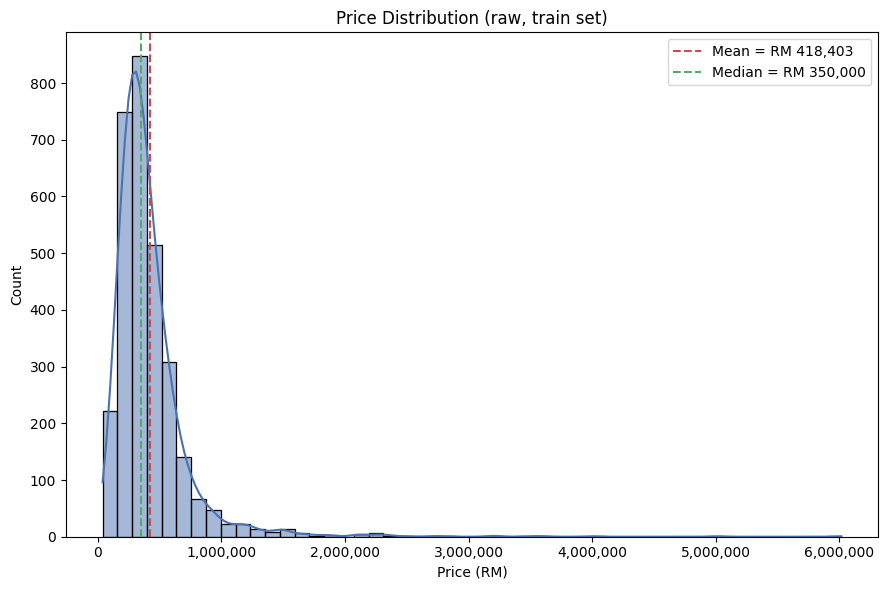

In [5]:
print("=" * 60)
print("4.1.1: PRICE DISTRIBUTION AND CENTRAL TENDENCY")
print("=" * 60)

mean_p, median_p = price.mean(), price.median()
mode_p = price.mode().iloc[0]
std_p, min_p, max_p = price.std(), price.min(), price.max()

print(f"Mean:   RM {mean_p:,.2f}")
print(f"Median: RM {median_p:,.2f}")
print(f"Mode:   RM {mode_p:,.0f}  ({(price == mode_p).sum()} listings share this price)")
print(f"Std:    RM {std_p:,.2f}")
print(f"Min:    RM {min_p:,.0f}")
print(f"Max:    RM {max_p:,.0f}")

skew_raw = stats.skew(price)
if skew_raw > 0.5:
    direction = "right-skewed (long tail toward high prices)"
elif skew_raw < -0.5:
    direction = "left-skewed (long tail toward low prices)"
else:
    direction = "approximately symmetrical"
print(f"Skewness: {skew_raw:.3f} -> {direction}")

fig, ax = plt.subplots(figsize=(9, 6))
sns.histplot(price, kde=True, bins=50, color="#4C72B0", ax=ax)
ax.axvline(mean_p, color="#C44E52", linestyle="--", label=f"Mean = RM {mean_p:,.0f}")
ax.axvline(median_p, color="#55A868", linestyle="--", label=f"Median = RM {median_p:,.0f}")
ax.set_xlabel("Price (RM)")
ax.set_ylabel("Count")
ax.set_title("Price Distribution (raw, train set)")
ax.legend()
show_full_numbers(ax, 'x')
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "fig_411_price_hist_kde.png"), dpi=150, bbox_inches="tight")
print("Saved: fig_411_price_hist_kde.png")


## 4.1.2 Skewness and Normality Assessment

Compares raw price's skewness against its log10-transformed version, and explains why the model trains on the log scale.


4.1.2: SKEWNESS AND NORMALITY ASSESSMENT
Raw price skewness:      5.633
log10(price) skewness:   0.229


Saved: fig_412_price_log_comparison.png


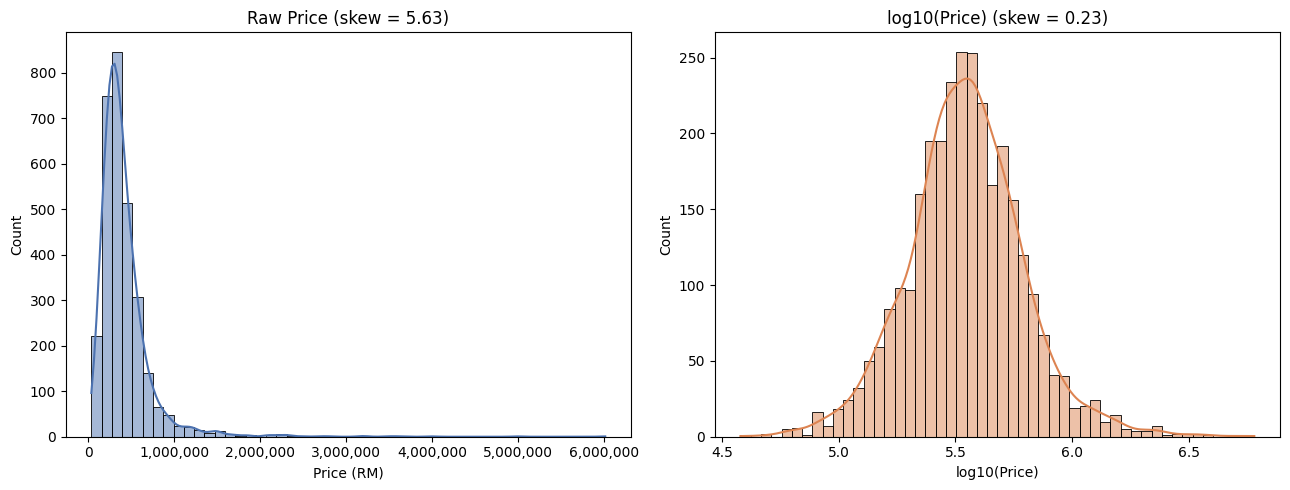

In [6]:
print("\n" + "=" * 60)
print("4.1.2: SKEWNESS AND NORMALITY ASSESSMENT")
print("=" * 60)

log_price = np.log10(price)
skew_log = stats.skew(log_price)

print(f"Raw price skewness:      {skew_raw:.3f}")
print(f"log10(price) skewness:   {skew_log:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(price, kde=True, bins=50, color="#4C72B0", ax=axes[0])
axes[0].set_title(f"Raw Price (skew = {skew_raw:.2f})")
axes[0].set_xlabel("Price (RM)")
show_full_numbers(axes[0], 'x')

sns.histplot(log_price, kde=True, bins=50, color="#DD8452", ax=axes[1])
axes[1].set_title(f"log10(Price) (skew = {skew_log:.2f})")
axes[1].set_xlabel("log10(Price)")

plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "fig_412_price_log_comparison.png"), dpi=150, bbox_inches="tight")

print("Saved: fig_412_price_log_comparison.png")

## 4.1.3 Price Distribution across Property Categories

Compares price distribution across the four major Property Type categories.


4.1.3: PRICE DISTRIBUTION ACROSS PROPERTY CATEGORIES
Rows in major 4 categories: 3004 / 3004 (0 excluded as minor categories: {})
                   Count      Mean    Median       IQR    Min      Max  \
Property Type                                                            
Condominium         1276  566253.0  470000.0  260000.0  48000  6016000   
Service Residence    393  481272.0  443000.0  200000.0  38000  2300000   
Apartment           1144  275455.0  268000.0  118000.0  50000  1200000   
Flat                 191  157507.0  155000.0   70000.0  62000   360000   

                        Std  
Property Type                
Condominium        419046.0  
Service Residence  227213.0  
Apartment          104101.0  
Flat                52758.0  

Highest median price: Condominium (RM 470,000)
Most price variance:  Condominium (std = RM 419,046)

Eta-squared (Property Type vs log10_price): 0.4240 -> Property Type alone explains 42.4% of the variance in log10(price) (equivalent r ~ 0.651

Saved: fig_413_price_by_property_type.png


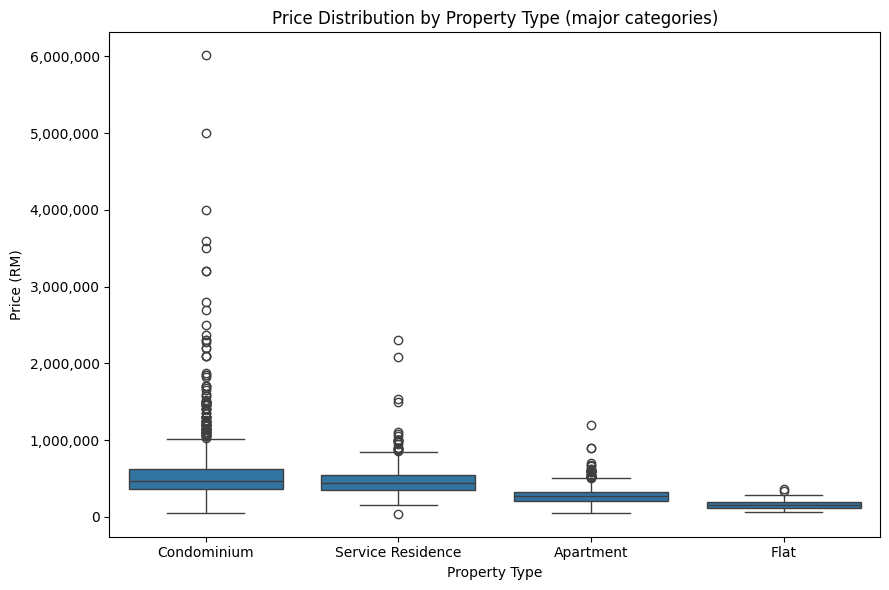

In [7]:
print("\n" + "=" * 60)
print("4.1.3: PRICE DISTRIBUTION ACROSS PROPERTY CATEGORIES")
print("=" * 60)

major_categories = ['Condominium', 'Apartment', 'Service Residence', 'Flat']
is_major = df['Property Type'].isin(major_categories)
sub = df[is_major].copy()
excluded_counts = df.loc[~is_major, 'Property Type'].value_counts().to_dict()
print(f"Rows in major 4 categories: {len(sub)} / {len(df)} "
      f"({len(df) - len(sub)} excluded as minor categories: {excluded_counts})")

summary = sub.groupby('Property Type')['price'].agg(
    Count='count', Mean='mean', Median='median',
    Q1=lambda s: s.quantile(0.25), Q3=lambda s: s.quantile(0.75),
    Min='min', Max='max', Std='std'
)
summary['IQR'] = summary['Q3'] - summary['Q1']
summary = summary[['Count', 'Mean', 'Median', 'IQR', 'Min', 'Max', 'Std']]
summary = summary.sort_values('Median', ascending=False)
print(summary.round(0))

highest_median_cat = summary['Median'].idxmax()
highest_var_cat = summary['Std'].idxmax()
print(f"\nHighest median price: {highest_median_cat} (RM {summary.loc[highest_median_cat, 'Median']:,.0f})")
print(f"Most price variance:  {highest_var_cat} (std = RM {summary.loc[highest_var_cat, 'Std']:,.0f})")

log10_price_type = np.log10(sub["price"])
eta_sq_type = eta_squared(
    pd.DataFrame({"Property Type": sub["Property Type"], "log10_price": log10_price_type}),
    "Property Type", "log10_price")
print(f"\nEta-squared (Property Type vs log10_price): {eta_sq_type:.4f} "
      f"-> Property Type alone explains {eta_sq_type * 100:.1f}% of the variance in log10(price) "
      f"(equivalent r ~ {eta_sq_type ** 0.5:.3f})")

fig, ax = plt.subplots(figsize=(9, 6))
order = summary.index.tolist()
sns.boxplot(data=sub, x='Property Type', y='price', order=order, ax=ax)
ax.set_ylabel("Price (RM)")
ax.set_title("Price Distribution by Property Type (major categories)")
show_full_numbers(ax, 'y')
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "fig_413_price_by_property_type.png"), dpi=150, bbox_inches="tight")

print("Saved: fig_413_price_by_property_type.png")


## 4.2.1 Continous Numetical Variables - Property Size (sq.ft.)

Examines Property Size's distribution, flags IQR outliers, and compares it before/after a log transform.


SECTION 4.2.1: PROPERTY SIZE (sq.ft.)



--- Summary Statistics ---
      Statistic       Value
           Mean  994.625375
         Median  904.000000
25th Percentile  750.000000
75th Percentile 1115.000000
            Min  280.000000
            Max 9376.000000

--- Outlier Detection (IQR method) ---
Lower bound: 202.5 sq.ft.
Upper bound: 1662.5 sq.ft.
Number of outliers: 115 (3.8% of data)

Top 10 largest properties (potential outliers):
 Property Size  Bedroom  Bathroom   price
        9376.0        4         2  250000
        6800.0        6         5 5000000
        6016.0        5         7 6016000
        6000.0        5         5 2700000
        6000.0        4         4 3200000
        5619.0        4         5 4000000
        5000.0        5         5 2500000
        4800.0        4         4 2300000
        4500.0        3         3 3499999
        4370.0        5         7 1480000



--- Skewness Comparison ---
        Version  Skewness
       Original  5.879364
Log-Transformed  0.879166

[4.2.1] Figures saved to: C:\DS assignment\Malaysian-Condominium-Prices-Data\data\eda
  fig_421_property_size_hist.png
  fig_421_property_size_box.png
  fig_421_property_size_log_comparison.png


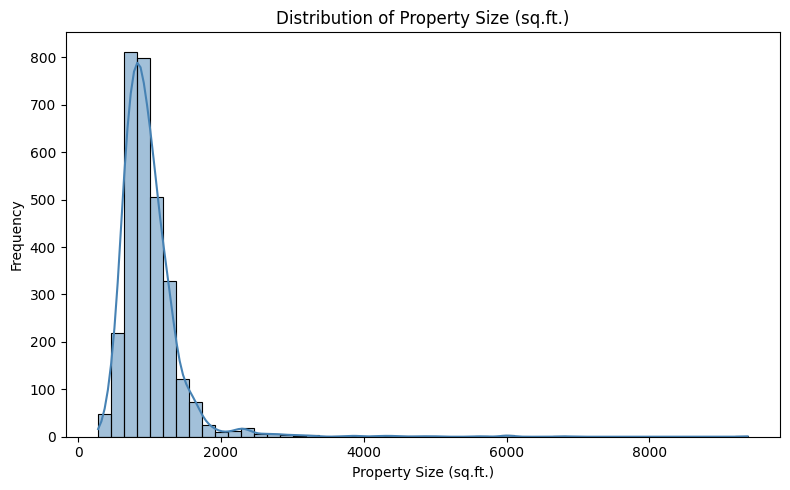

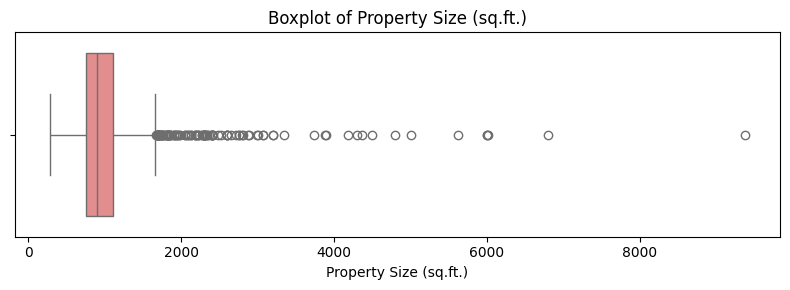

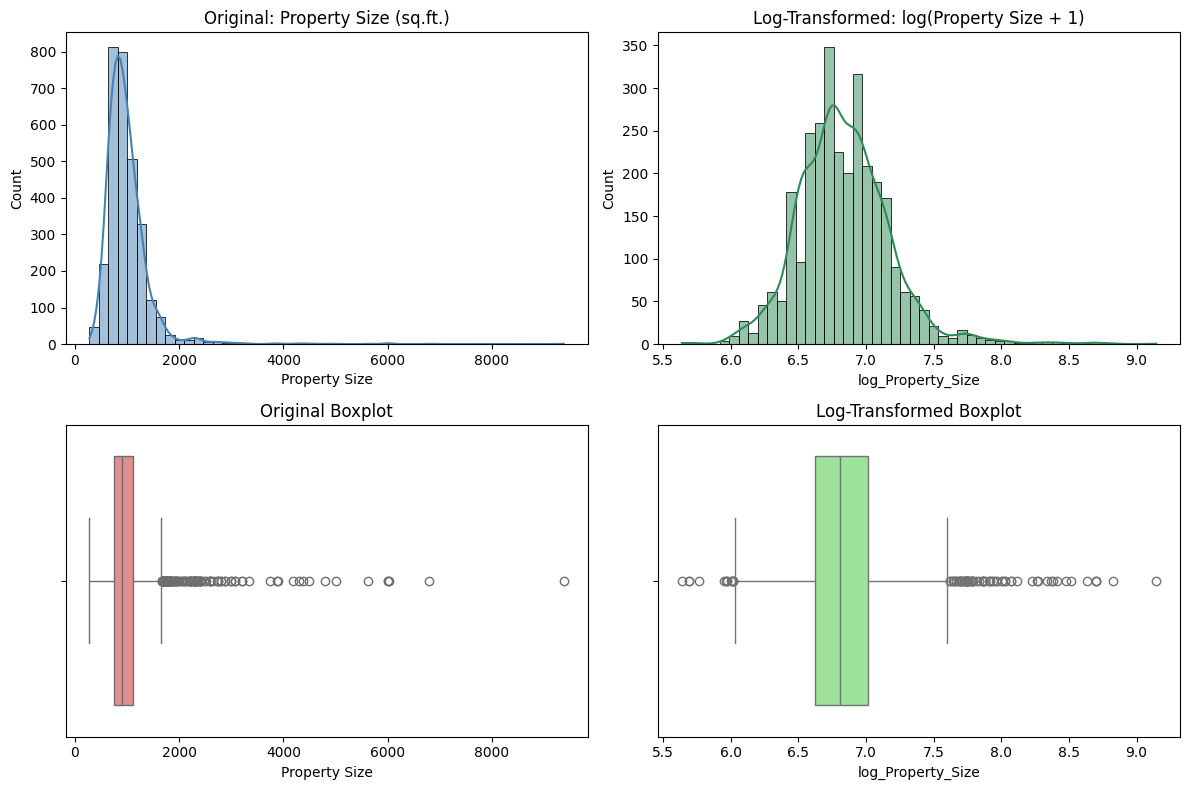

In [8]:
print("\n" + "=" * 60)
print("SECTION 4.2.1: PROPERTY SIZE (sq.ft.)")
print("=" * 60)

size = df['Property Size'].dropna()

# --- Histogram ---
plt.figure(figsize=(8, 5))
sns.histplot(size, bins=50, kde=True, color='steelblue')
plt.title('Distribution of Property Size (sq.ft.)')
plt.xlabel('Property Size (sq.ft.)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "fig_421_property_size_hist.png"), dpi=150, bbox_inches="tight")


# --- Boxplot ---
plt.figure(figsize=(8, 3))
sns.boxplot(x=size, color='lightcoral')
plt.title('Boxplot of Property Size (sq.ft.)')
plt.xlabel('Property Size (sq.ft.)')
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "fig_421_property_size_box.png"), dpi=150, bbox_inches="tight")


# --- Summary statistics ---
summary_table = pd.DataFrame({
    'Statistic': ['Mean', 'Median', '25th Percentile', '75th Percentile', 'Min', 'Max'],
    'Value': [
        size.mean(), size.median(), size.quantile(0.25),
        size.quantile(0.75), size.min(), size.max()
    ]
})
print("\n--- Summary Statistics ---")
print(summary_table.to_string(index=False))

# --- Outlier detection (IQR method) ---
Q1 = size.quantile(0.25)
Q3 = size.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Property Size'] < lower_bound) | (df['Property Size'] > upper_bound)]
size_cols = [c for c in ['Property Size', 'Bedroom', 'Bathroom', 'price'] if c in df.columns]
outliers_top10 = outliers.sort_values('Property Size', ascending=False)[size_cols].head(10)

print("\n--- Outlier Detection (IQR method) ---")
print(f"Lower bound: {lower_bound:.1f} sq.ft.")
print(f"Upper bound: {upper_bound:.1f} sq.ft.")
print(f"Number of outliers: {len(outliers)} ({len(outliers) / len(df) * 100:.1f}% of data)")
print("\nTop 10 largest properties (potential outliers):")
print(outliers_top10.to_string(index=False))

# --- Log transform (to address right skew) ---
df['log_Property_Size'] = np.log1p(df['Property Size'])
log_size = df['log_Property_Size'].dropna()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(size, bins=50, kde=True, color='steelblue', ax=axes[0, 0])
axes[0, 0].set_title('Original: Property Size (sq.ft.)')
sns.histplot(log_size, bins=50, kde=True, color='seagreen', ax=axes[0, 1])
axes[0, 1].set_title('Log-Transformed: log(Property Size + 1)')
sns.boxplot(x=size, color='lightcoral', ax=axes[1, 0])
axes[1, 0].set_title('Original Boxplot')
sns.boxplot(x=log_size, color='lightgreen', ax=axes[1, 1])
axes[1, 1].set_title('Log-Transformed Boxplot')
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "fig_421_property_size_log_comparison.png"), dpi=150, bbox_inches="tight")


skew_table = pd.DataFrame({
    'Version': ['Original', 'Log-Transformed'],
    'Skewness': [stats.skew(size), stats.skew(log_size)]
})
print("\n--- Skewness Comparison ---")
print(skew_table.to_string(index=False))

print(f"\n[4.2.1] Figures saved to: {EDA_DIR}")
print("  fig_421_property_size_hist.png")
print("  fig_421_property_size_box.png")
print("  fig_421_property_size_log_comparison.png")


## 4.2.2 DISCRETE NUMERICAL VARIABLES - Bedroom, Bathroom, Parking Lot

Shows the count distribution and mode for Bedroom, Bathroom, and Parking Lot.


SECTION 4.2.2: DISCRETE NUMERICAL VARIABLES


Saved: fig_422_bedroom_countplot.png


Saved: fig_422_bathroom_countplot.png


Saved: fig_422_parking_lot_countplot.png

--- Mode Summary (Bedroom / Bathroom / Parking Lot) ---
   Variable  Mode  Mode Count  Mode %  Missing
    Bedroom   3.0        2210    73.6        0
   Bathroom   2.0        2351    78.3        0
Parking Lot   1.0        1146    55.4      936

[4.2.2] Figures saved to: C:\DS assignment\Malaysian-Condominium-Prices-Data\data\eda
  fig_422_bedroom_countplot.png
  fig_422_bathroom_countplot.png
  fig_422_parking_lot_countplot.png


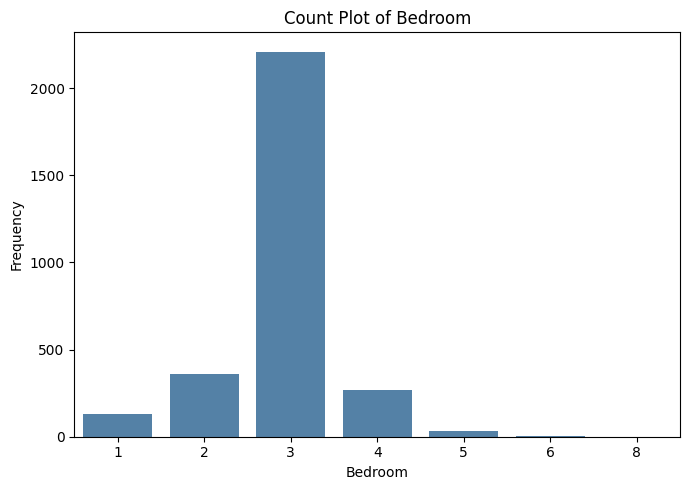

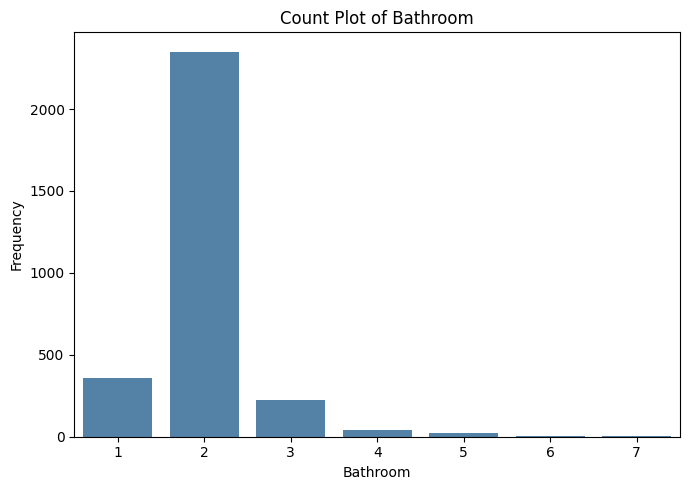

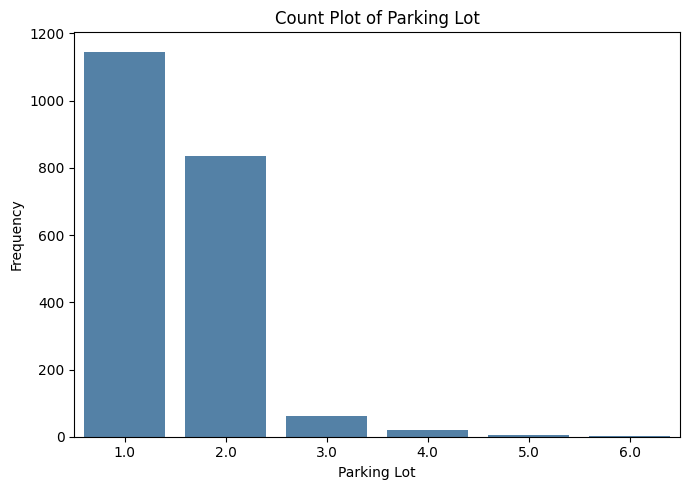

In [9]:
print("\n" + "=" * 60)
print("SECTION 4.2.2: DISCRETE NUMERICAL VARIABLES")
print("=" * 60)

DISCRETE_VARS = ['Bedroom', 'Bathroom', 'Parking Lot']

# --- Vertical bar plots (count plots) ---
for var in DISCRETE_VARS:
    counts = df[var].value_counts().sort_index()

    plt.figure(figsize=(7, 5))
    sns.countplot(x=df[var].dropna(), color='steelblue', order=counts.index)
    plt.title(f'Count Plot of {var}')
    plt.xlabel(var)
    plt.ylabel('Frequency')
    plt.tight_layout()

    fname = f"fig_422_{var.replace(' ', '_').lower()}_countplot.png"
    plt.savefig(os.path.join(EDA_DIR, fname), dpi=150, bbox_inches="tight")
    
    print(f"Saved: {fname}")

# --- Mode identification ---
mode_rows = []
for var in DISCRETE_VARS:
    s = df[var].dropna()
    mode_val = s.mode().iloc[0]          # first mode if multiple exist
    mode_count = (s == mode_val).sum()
    mode_pct = mode_count / len(s) * 100
    mode_rows.append({
        'Variable': var,
        'Mode': mode_val,
        'Mode Count': mode_count,
        'Mode %': round(mode_pct, 1),
        'Missing': df[var].isna().sum()
    })

mode_table = pd.DataFrame(mode_rows)
print("\n--- Mode Summary (Bedroom / Bathroom / Parking Lot) ---")
print(mode_table.to_string(index=False))

print(f"\n[4.2.2] Figures saved to: {EDA_DIR}")
for var in DISCRETE_VARS:
    print(f"  fig_422_{var.replace(' ', '_').lower()}_countplot.png")


## 4.2.3 CATEGORICAL VARIABLE DISTRIBUTIONS - Tenure Type, Land Title, Property Type

Shows the class distribution for Tenure Type, Land Title, and Property Type.


SECTION 4.2.3: CATEGORICAL VARIABLE DISTRIBUTIONS



--- Tenure Type: Frequency Table ---
Tenure Type  Count  Percentage
   Freehold   1830        60.9
  Leasehold   1174        39.1
Saved: fig_423_tenure_type_barchart.png

--- Land Title: Frequency Table ---
  Land Title  Count  Percentage
Non Bumi Lot   2526        84.1
    Bumi Lot    478        15.9


Saved: fig_423_land_title_barchart.png

--- Property Type: Frequency Table ---
    Property Type  Count  Percentage
      Condominium   1276        42.5
        Apartment   1144        38.1
Service Residence    393        13.1
             Flat    191         6.4
Saved: fig_423_property_type_barchart.png

--- Major Category Splits ---
           Comparison   Category A  Count A Category B  Count B  A %  B %
Freehold vs Leasehold     Freehold     1830  Leasehold     1174 60.9 39.1
 Non-Bumi vs Bumi Lot Non Bumi Lot     2526   Bumi Lot      478 84.1 15.9

[4.2.3] Figures saved to: C:\DS assignment\Malaysian-Condominium-Prices-Data\data\eda
  fig_423_tenure_type_barchart.png
  fig_423_land_title_barchart.png
  fig_423_property_type_barchart.png

All of Section 4.2 complete (4.2.1-4.2.3).


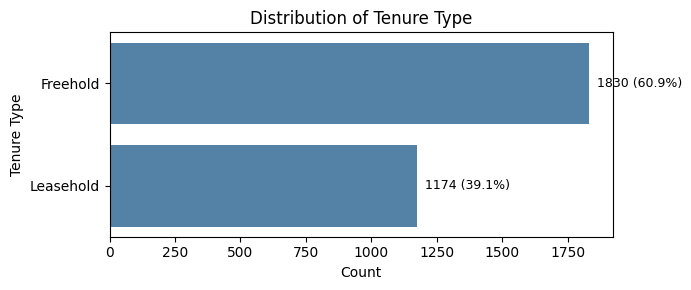

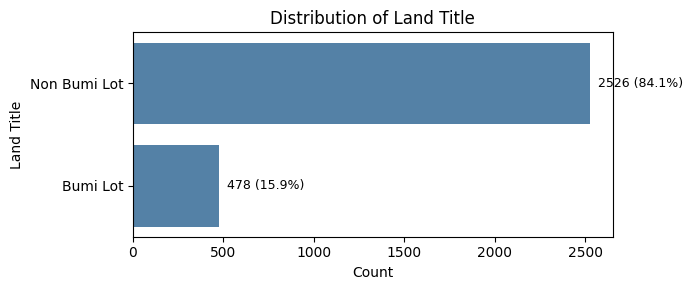

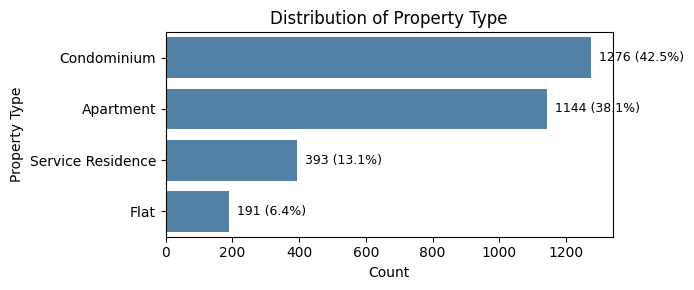

In [10]:
print("\n" + "=" * 60)
print("SECTION 4.2.3: CATEGORICAL VARIABLE DISTRIBUTIONS")
print("=" * 60)

CATEGORICAL_VARS = ['Tenure Type', 'Land Title', 'Property Type']

cat_freq_tables = {}   # kept so the proportions block below can reuse them

for var in CATEGORICAL_VARS:
    counts = df[var].value_counts(dropna=False)
    pct = (counts / len(df) * 100).round(1)
    freq_table = pd.DataFrame({
        var: counts.index.astype(str),
        'Count': counts.values,
        'Percentage': pct.values
    }).sort_values('Count', ascending=False).reset_index(drop=True)
    cat_freq_tables[var] = freq_table

    print(f"\n--- {var}: Frequency Table ---")
    print(freq_table.to_string(index=False))

    # --- Horizontal bar chart ---
    plt.figure(figsize=(7, max(3, 0.5 * len(freq_table))))
    order = freq_table[var]
    sns.barplot(
        y=freq_table[var].astype(str), x=freq_table['Count'],
        color='steelblue', order=order
    )
    plt.title(f'Distribution of {var}')
    plt.xlabel('Count')
    plt.ylabel(var)
    for i, (count, pct_val) in enumerate(zip(freq_table['Count'], freq_table['Percentage'])):
        plt.text(count, i, f"  {count} ({pct_val}%)", va='center', fontsize=9)
    plt.tight_layout()

    fname = f"fig_423_{var.replace(' ', '_').lower()}_barchart.png"
    plt.savefig(os.path.join(EDA_DIR, fname), dpi=150, bbox_inches="tight")
    
    print(f"Saved: {fname}")

# --- Proportions for major category splits (as report call-outs) ---
print("\n--- Major Category Splits ---")
major_split_rows = []

if set(['Freehold', 'Leasehold']).issubset(set(df['Tenure Type'].dropna().unique())):
    t = df['Tenure Type'].value_counts()
    major_split_rows.append({
        'Comparison': 'Freehold vs Leasehold',
        'Category A': 'Freehold', 'Count A': int(t.get('Freehold', 0)),
        'Category B': 'Leasehold', 'Count B': int(t.get('Leasehold', 0)),
        'A %': round(t.get('Freehold', 0) / t.sum() * 100, 1),
        'B %': round(t.get('Leasehold', 0) / t.sum() * 100, 1),
    })

if set(['Non Bumi Lot', 'Bumi Lot']).issubset(set(df['Land Title'].dropna().unique())):
    l = df['Land Title'].value_counts()
    major_split_rows.append({
        'Comparison': 'Non-Bumi vs Bumi Lot',
        'Category A': 'Non Bumi Lot', 'Count A': int(l.get('Non Bumi Lot', 0)),
        'Category B': 'Bumi Lot', 'Count B': int(l.get('Bumi Lot', 0)),
        'A %': round(l.get('Non Bumi Lot', 0) / l.sum() * 100, 1),
        'B %': round(l.get('Bumi Lot', 0) / l.sum() * 100, 1),
    })

major_split_table = pd.DataFrame(major_split_rows)
print(major_split_table.to_string(index=False))

print(f"\n[4.2.3] Figures saved to: {EDA_DIR}")
for var in CATEGORICAL_VARS:
    print(f"  fig_423_{var.replace(' ', '_').lower()}_barchart.png")

print(f"\nAll of Section 4.2 complete (4.2.1-4.2.3).")


## 4.3.1 Correlation Matrix and Heatmap

Correlates core numeric features and amenity flags against log10(price).


STEP 4.3.1: CORRELATION MATRIX AND HEATMAP

--- Core feature correlation with log10_price ---
Property Size            0.616801
Bathroom                 0.524114
Parking Lot              0.521192
Listed_Facility_Count    0.442522
# of Floors              0.438424
Bedroom                  0.280359
Is_Non_Bumi_Lot          0.213536
Freehold Indicator       0.169022
Floor_Range_Ordinal      0.106136
Total Units             -0.150308
Property Age            -0.296152
Name: log10_price, dtype: float64



Saved: fig_431_correlation_heatmap.png

--- Amenity correlation with log10_price ---
Has_Gymnasium            0.493350
Has_Swimming_Pool        0.468872
Has_Security             0.369551
Has_Sauna                0.354530
Has_Barbeque_Area        0.339510
Has_Lift                 0.282882
Has_Playground           0.276668
Has_Multipurpose_Hall    0.271490
Has_Parking              0.256404
Has_Squash_Court         0.245861
Has_Jogging_Track        0.216273
Has_Tennis_Court         0.204110
Has_Club_House           0.189527
Has_Mall                 0.070637
Has_Railway_Station      0.048799
Has_Minimart             0.046375
Has_Bus_Stop             0.021676
Has_Hospital             0.016687
Has_Highway              0.012234
Has_Park                 0.012111
Has_School              -0.014342
Name: log10_price, dtype: float64



Saved: fig_431_amenity_correlation.png


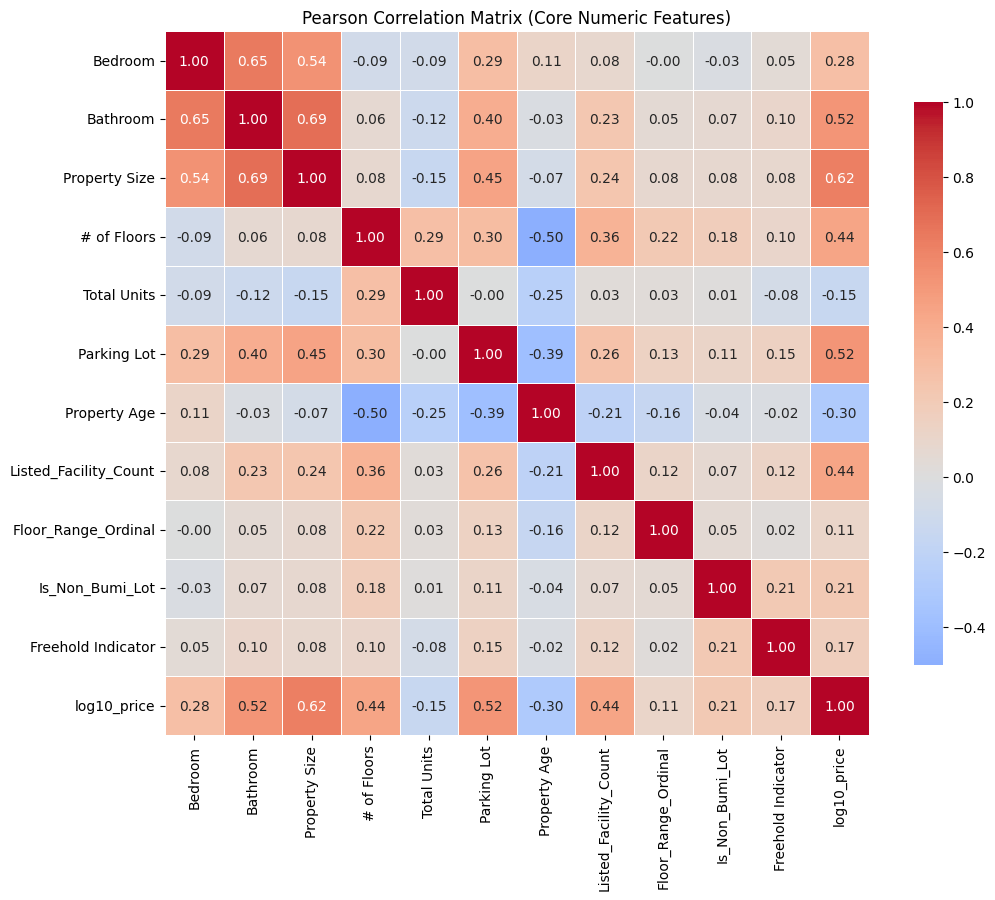

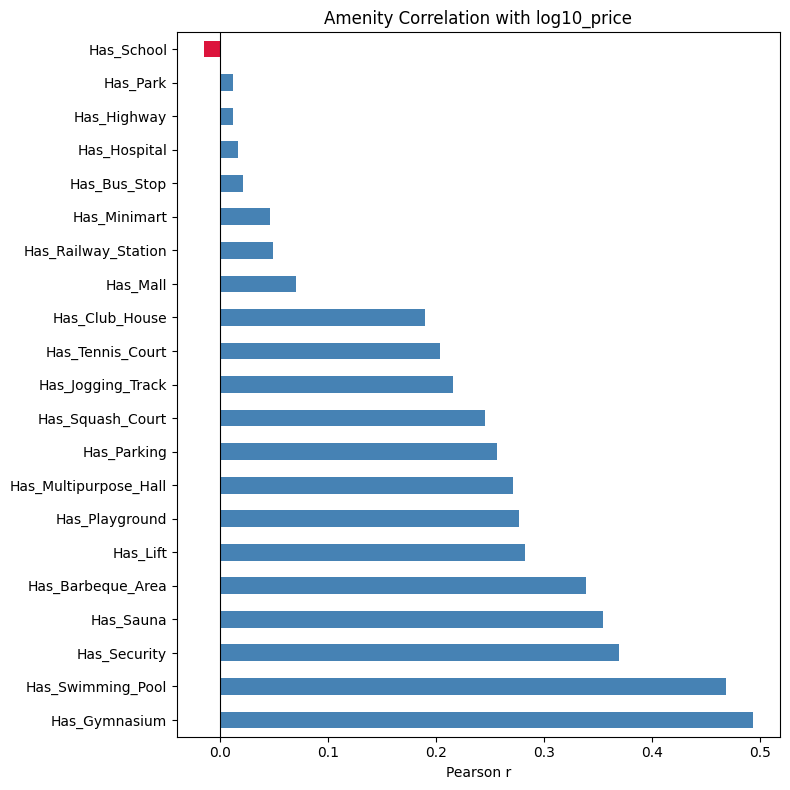

In [11]:
df['log10_price'] = np.log10(df['price'])

print("\n" + "=" * 60)
print("STEP 4.3.1: CORRELATION MATRIX AND HEATMAP")
print("=" * 60)

CORE_COLS = ['Bedroom', 'Bathroom', 'Property Size', '# of Floors', 'Total Units',
             'Parking Lot', 'Property Age', 'Listed_Facility_Count',
             'Floor_Range_Ordinal', 'Is_Non_Bumi_Lot', 'Freehold Indicator',
             'log10_price']

core_corr = df[CORE_COLS].corr(method='pearson')
core_corr_vs_price = core_corr['log10_price'].drop('log10_price').sort_values(ascending=False)

print("\n--- Core feature correlation with log10_price ---")
print(core_corr_vs_price)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(core_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Pearson Correlation Matrix (Core Numeric Features)")
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "fig_431_correlation_heatmap.png"), dpi=150, bbox_inches="tight")

print(f"\nSaved: fig_431_correlation_heatmap.png")

AMENITY_COLS = [c for c in df.columns if c.startswith('Has_')]

amenity_corr = df[AMENITY_COLS + ['log10_price']].corr()['log10_price'].drop('log10_price').sort_values(ascending=False)

print("\n--- Amenity correlation with log10_price ---")
print(amenity_corr)

fig, ax = plt.subplots(figsize=(8, 8))
colors = ['crimson' if v < 0 else 'steelblue' for v in amenity_corr]
amenity_corr.plot(kind='barh', ax=ax, color=colors)
ax.set_title("Amenity Correlation with log10_price")
ax.set_xlabel("Pearson r")
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "fig_431_amenity_correlation.png"), dpi=150, bbox_inches="tight")

print(f"\nSaved: fig_431_amenity_correlation.png")


## 4.3.2 Price vs. Property Size Interaction

Visualises Price vs Property Size (filtered for readability), coloured by Bedroom count, and fits a linear trend line.


STEP 4.3.2: PRICE VS PROPERTY SIZE INTERACTION

Total rows: 3004
Rows excluded by filter (>= 3000 sqft OR >= RM2,000,000): 31 (1.03%)



Saved: fig_432_price_vs_property_size.png

Linear fit: price = 493.63 * Property_Size + (-77672.99)
Pearson r (filtered subset): 0.684



Saved: fig_432_trend_line.png


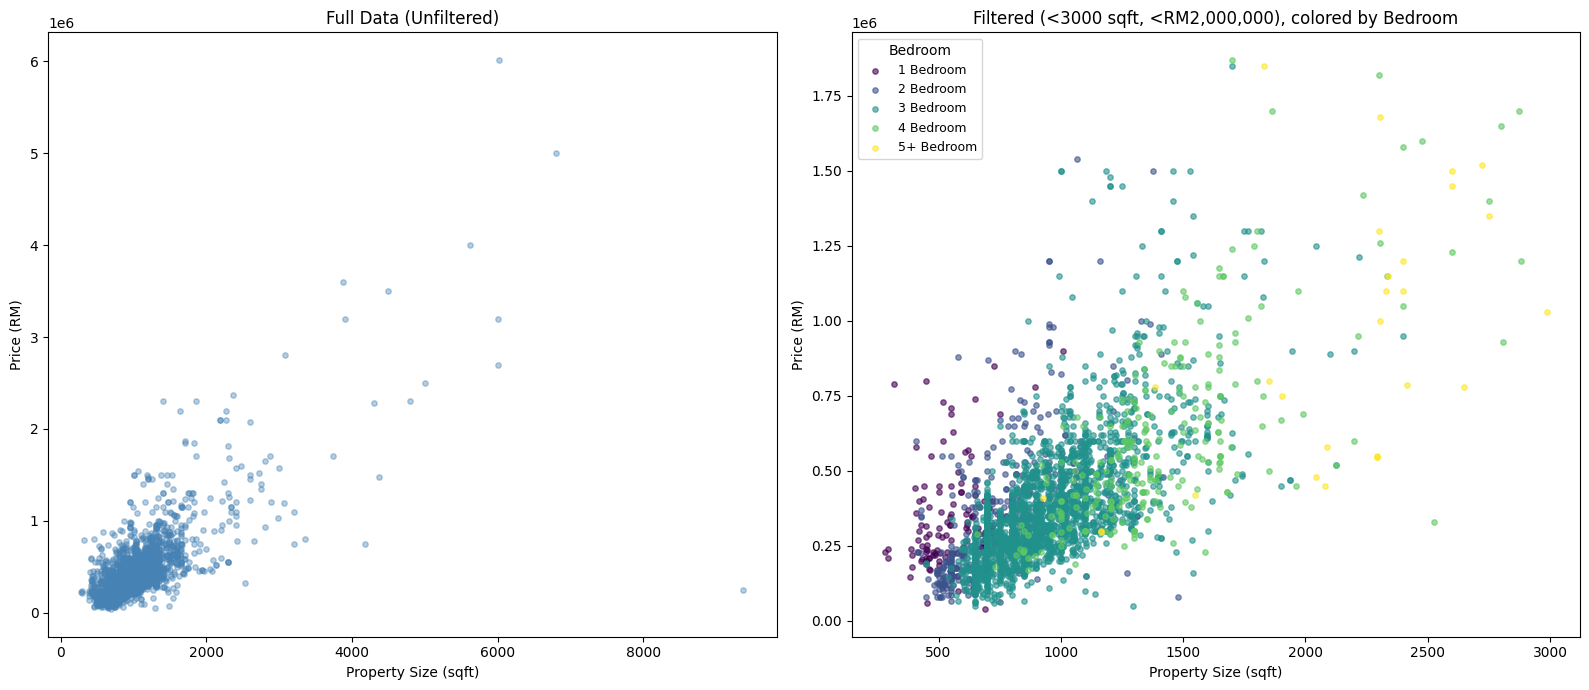

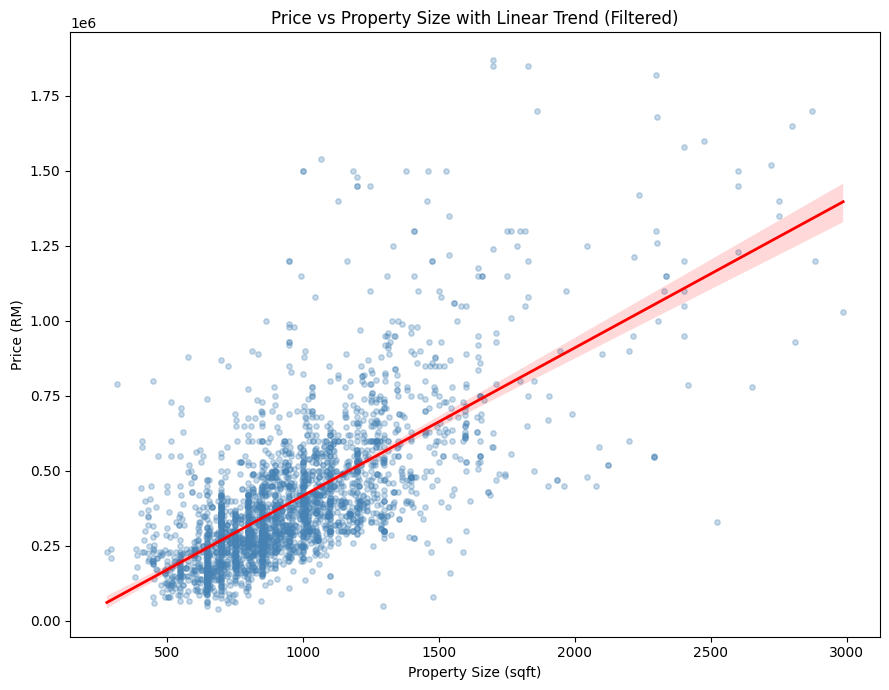

In [12]:
print("\n" + "=" * 60)
print("STEP 4.3.2: PRICE VS PROPERTY SIZE INTERACTION")
print("=" * 60)

df['Bedroom_Group'] = df['Bedroom'].apply(lambda x: '5+' if x >= 5 else str(int(x)))

SIZE_LIMIT = 3000
PRICE_LIMIT = 2_000_000

mask = (df['Property Size'] < SIZE_LIMIT) & (df['price'] < PRICE_LIMIT)
filtered = df[mask]

n_excluded = len(df) - len(filtered)
print(f"\nTotal rows: {len(df)}")
print(f"Rows excluded by filter (>= {SIZE_LIMIT} sqft OR >= RM{PRICE_LIMIT:,}): {n_excluded} "
      f"({n_excluded/len(df)*100:.2f}%)")

bedroom_order = sorted(filtered['Bedroom_Group'].unique(),
                        key=lambda x: 99 if x == '5+' else int(x))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].scatter(df['Property Size'], df['price'],
                 s=15, alpha=0.4, color='steelblue')
axes[0].set_title("Full Data (Unfiltered)")
axes[0].set_xlabel("Property Size (sqft)")
axes[0].set_ylabel("Price (RM)")

palette = plt.cm.viridis(np.linspace(0, 1, len(bedroom_order)))
for color, grp in zip(palette, bedroom_order):
    subset = filtered[filtered['Bedroom_Group'] == grp]
    axes[1].scatter(subset['Property Size'], subset['price'],
                     s=15, alpha=0.6, color=color, label=f"{grp} Bedroom")

axes[1].set_title(f"Filtered (<{SIZE_LIMIT} sqft, <RM{PRICE_LIMIT:,}), colored by Bedroom")
axes[1].set_xlabel("Property Size (sqft)")
axes[1].set_ylabel("Price (RM)")
axes[1].legend(title="Bedroom", loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "fig_432_price_vs_property_size.png"), dpi=150, bbox_inches="tight")

print(f"\nSaved: fig_432_price_vs_property_size.png")

# ------------------------------------------------------------
# 4.3.2b Price vs Property Size — Linear Trend
# ------------------------------------------------------------
slope, intercept = np.polyfit(filtered['Property Size'], filtered['price'], 1)
r_value = filtered['Property Size'].corr(filtered['price'])

print(f"\nLinear fit: price = {slope:.2f} * Property_Size + ({intercept:.2f})")
print(f"Pearson r (filtered subset): {r_value:.3f}")

fig, ax = plt.subplots(figsize=(9, 7))
sns.regplot(data=filtered, x='Property Size', y='price',
            scatter_kws={'alpha': 0.3, 's': 15, 'color': 'steelblue'},
            line_kws={'color': 'red', 'linewidth': 2},
            ax=ax)
ax.set_title("Price vs Property Size with Linear Trend (Filtered)")
ax.set_xlabel("Property Size (sqft)")
ax.set_ylabel("Price (RM)")
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "fig_432_trend_line.png"), dpi=150, bbox_inches="tight")

print(f"\nSaved: fig_432_trend_line.png")


## 4.3.3 Price vs. Room Features

Compares price distribution across Bedroom and Bathroom count groups.


STEP 4.3.3: PRICE VS ROOM FEATURES

--- Median price by Bedroom group ---
Bedroom_Group4
1     292500.0
2     338000.0
3     340000.0
4+    570000.0
Name: price, dtype: float64

--- Median price by Bathroom group ---
Bathroom_Group
1      220000.0
2      350000.0
3      642500.0
4+    1254000.0
Name: price, dtype: float64



Saved: fig_433_price_vs_room_features.png


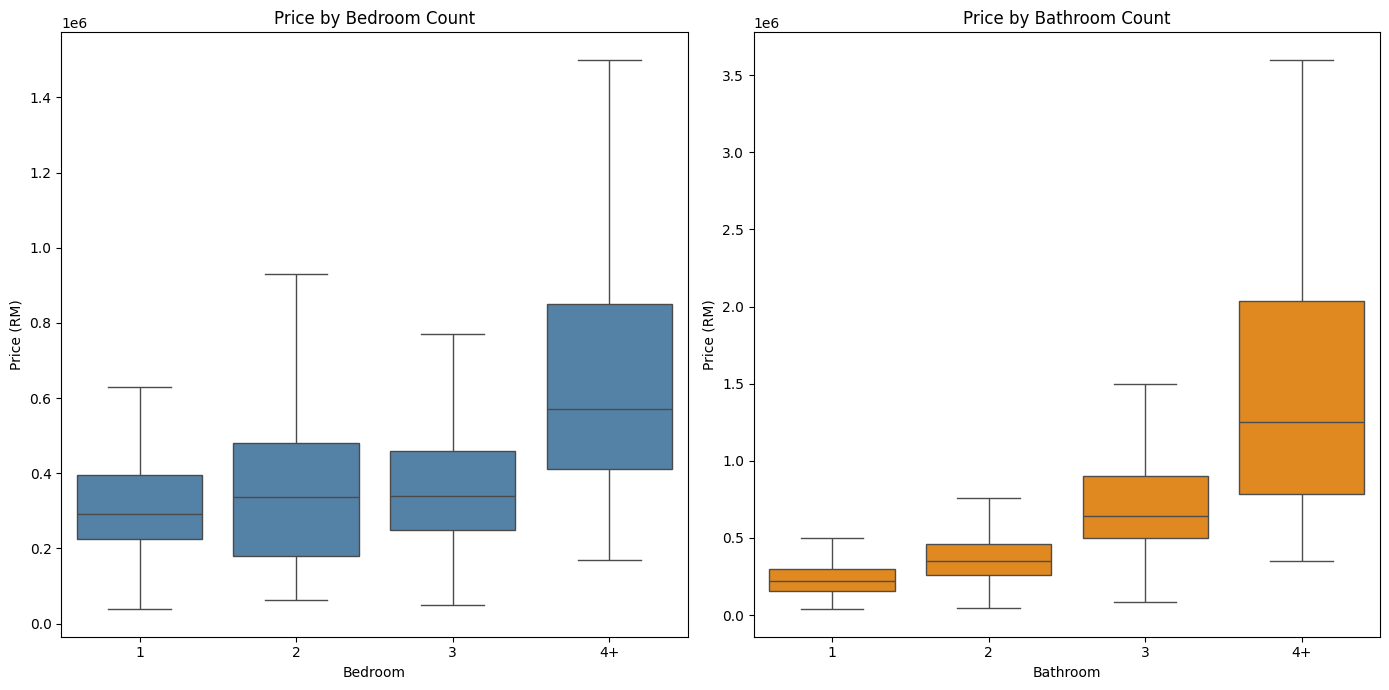

In [13]:
print("\n" + "=" * 60)
print("STEP 4.3.3: PRICE VS ROOM FEATURES")
print("=" * 60)

df['Bathroom_Group'] = df['Bathroom'].apply(lambda x: '4+' if x >= 4 else str(int(x)))
df['Bedroom_Group4'] = df['Bedroom'].apply(lambda x: '4+' if x >= 4 else str(int(x)))

group_order = ['1', '2', '3', '4+']

median_by_bedroom = df.groupby('Bedroom_Group4')['price'].median().reindex(group_order)
median_by_bathroom = df.groupby('Bathroom_Group')['price'].median().reindex(group_order)

print("\n--- Median price by Bedroom group ---")
print(median_by_bedroom)

print("\n--- Median price by Bathroom group ---")
print(median_by_bathroom)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

sns.boxplot(data=df, x='Bedroom_Group4', y='price', order=group_order,
            ax=axes[0], color='steelblue', showfliers=False)
axes[0].set_title("Price by Bedroom Count")
axes[0].set_xlabel("Bedroom")
axes[0].set_ylabel("Price (RM)")

sns.boxplot(data=df, x='Bathroom_Group', y='price', order=group_order,
            ax=axes[1], color='darkorange', showfliers=False)
axes[1].set_title("Price by Bathroom Count")
axes[1].set_xlabel("Bathroom")
axes[1].set_ylabel("Price (RM)")

plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "fig_433_price_vs_room_features.png"), dpi=150, bbox_inches="tight")

print(f"\nSaved: fig_433_price_vs_room_features.png")


## 4.3.4 Price vs Parking Lot Count

Compares price distribution across Parking Lot count groups.


STEP 4.3.4: PRICE VS PARKING LOT COUNT

Parking Lot missing: 936 (31.2%)

--- Median price by Parking Lot group ---
Parking_Group
1     325000.0
2     505000.0
3+    750000.0
Name: price, dtype: float64



Saved: fig_434_price_vs_parking_lot.png

All of Section 4.3 complete.


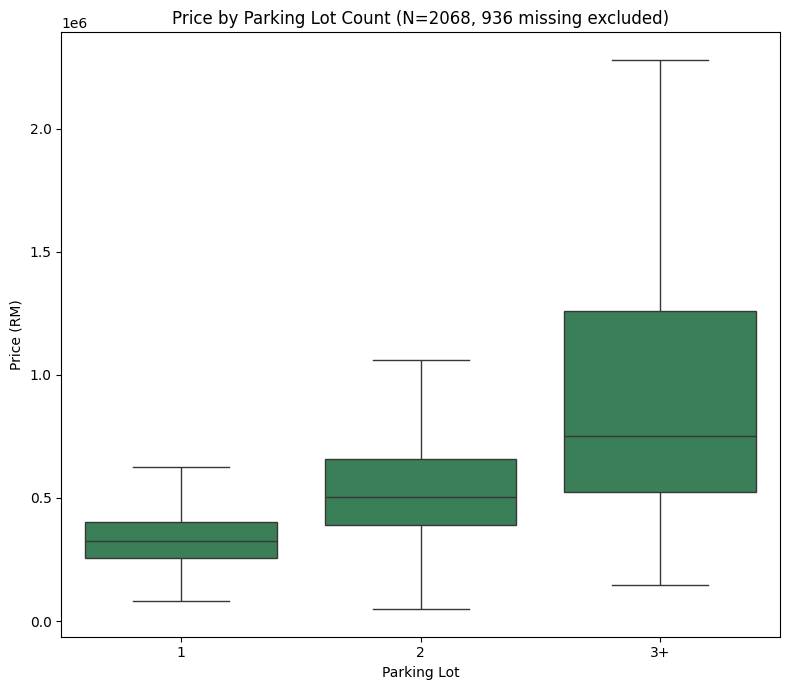

In [14]:
print("\n" + "=" * 60)
print("STEP 4.3.4: PRICE VS PARKING LOT COUNT")
print("=" * 60)

n_missing = df['Parking Lot'].isna().sum()
print(f"\nParking Lot missing: {n_missing} ({n_missing/len(df)*100:.1f}%)")

parking_plot_df = df.dropna(subset=['Parking Lot']).copy()
parking_plot_df['Parking_Group'] = parking_plot_df['Parking Lot'].apply(
    lambda x: '3+' if x >= 3 else str(int(x)))

parking_order = ['1', '2', '3+']

median_by_parking = parking_plot_df.groupby('Parking_Group')['price'].median().reindex(parking_order)
print("\n--- Median price by Parking Lot group ---")
print(median_by_parking)

fig, ax = plt.subplots(figsize=(8, 7))
sns.boxplot(data=parking_plot_df, x='Parking_Group', y='price', order=parking_order,
            ax=ax, color='seagreen', showfliers=False)
ax.set_title(f"Price by Parking Lot Count (N={len(parking_plot_df)}, "
             f"{n_missing} missing excluded)")
ax.set_xlabel("Parking Lot")
ax.set_ylabel("Price (RM)")
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "fig_434_price_vs_parking_lot.png"), dpi=150, bbox_inches="tight")

print(f"\nSaved: fig_434_price_vs_parking_lot.png")

print(f"\nAll of Section 4.3 complete.")


## 4.4.1 State-wise Price Pattern

Median price by State, ranked high to low (states with fewer than 20 records excluded, same threshold Section 3.2.3 used for rare Property Type categories).


STEP 4.4.1: STATE-WISE PRICE PATTERN
Rows with missing State (excluded from this pattern): 65

States excluded for having < 20 records (same threshold as Section 3.2.3):
State
Negeri Sembilan    16
Pahang             12
Perak              12
Kedah               2
Kelantan            1
Terengganu          1
Labuan              1
Name: count, dtype: int64

--- Median Price by State (reliable states only, ranked high to low) ---
              Count  Median_Price
State                            
Sabah           119      465000.0
Penang          765      450000.0
Putrajaya        48      433094.0
Kuala Lumpur    535      400000.0
Sarawak          98      390000.0
Johor           310      298944.0
Selangor        970      279999.5
Melaka           49      245000.0

Eta-squared (State vs log10_price): 0.1724 -> State alone explains 17.2% of the variance in log10(price) (equivalent r ~ 0.415)

Selangor: largest sample (n=970) but ranks 7 of 8 by price



Saved: fig_441_price_by_state.png


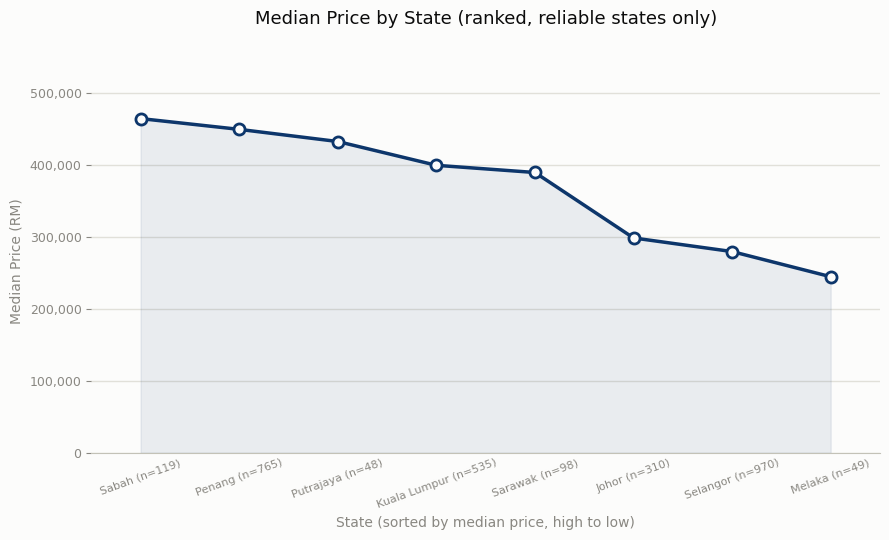

In [15]:
print("\n" + "=" * 60)
print("STEP 4.4.1: STATE-WISE PRICE PATTERN")
print("=" * 60)

n_state_missing = df["State"].isna().sum()
state_counts = df["State"].value_counts()
reliable_states = state_counts[state_counts >= 20].index
excluded_states = state_counts[state_counts < 20]

print(f"Rows with missing State (excluded from this pattern): {n_state_missing}")
print("\nStates excluded for having < 20 records (same threshold as Section 3.2.3):")
print(excluded_states)

state_trend = df[df["State"].isin(reliable_states)].groupby("State", observed=True)["price"].agg(
    Count="count", Median_Price="median").sort_values("Median_Price", ascending=False)
print("\n--- Median Price by State (reliable states only, ranked high to low) ---")
print(state_trend)

state_sub = df[df["State"].isin(reliable_states)]
log10_price_state = np.log10(state_sub["price"])
eta_sq_state = eta_squared(
    pd.DataFrame({"State": state_sub["State"], "log10_price": log10_price_state}),
    "State", "log10_price")
print(f"\nEta-squared (State vs log10_price): {eta_sq_state:.4f} "
      f"-> State alone explains {eta_sq_state * 100:.1f}% of the variance in log10(price) "
      f"(equivalent r ~ {eta_sq_state ** 0.5:.3f})")

selangor_rank = state_trend.index.get_loc("Selangor") + 1
selangor_count = int(state_trend.loc["Selangor", "Count"])
print(f"\nSelangor: largest sample (n={selangor_count}) but ranks {selangor_rank} of {len(state_trend)} by price")

state_labels = [f"{s} (n={int(c)})" for s, c in zip(state_trend.index, state_trend["Count"])]

plot_ordinal_line_trend(
    labels=state_labels,
    values=state_trend["Median_Price"].tolist(),
    title="Median Price by State (ranked, reliable states only)",
    xlabel="State (sorted by median price, high to low)",
    ylabel="Median Price (RM)",
    filename="fig_441_price_by_state.png",
    show_smoothed=False,
    markers=True,
    label_rotation=20,
)


## 4.4.2 Property Age Depreciation Pattern

Plots median price by property age (raw + smoothed), with reference markers for the 0-5 year median and the older-property plateau.


STEP 4.4.2: PROPERTY AGE DEPRECIATION PATTERN
Rows with missing Property Age (excluded from this pattern): 1536

--- Median Price by Property Age (every year) ---
              Count  Median_Price
Property Age                     
0.0              15      518000.0
1.0              31      750000.0
2.0              77      520000.0
3.0              67      520000.0
4.0              72      399000.0
5.0              66      566440.0
6.0             135      500000.0
7.0             119      480000.0
8.0              90      420000.0
9.0              86      420000.0
10.0             65      460000.0
11.0             36      389000.0
12.0             38      557500.0
13.0             56      355000.0
14.0             33      330000.0
15.0             46      382500.0
16.0             65      380000.0
17.0             49      339999.0
18.0             46      311000.0
19.0             20      332500.0
20.0             13      250000.0
21.0              8      247500.0
22.0             12 


Saved: fig_442_price_by_property_age.png


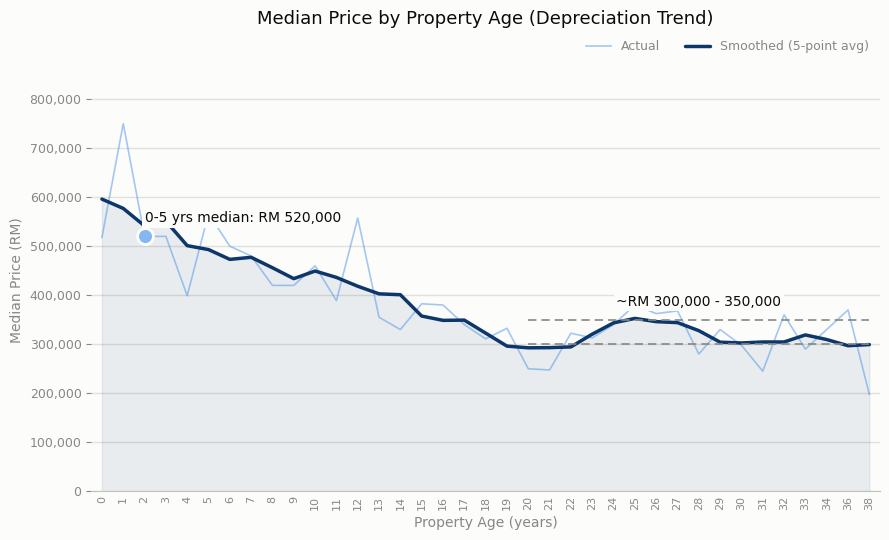

In [16]:
print("\n" + "=" * 60)
print("STEP 4.4.2: PROPERTY AGE DEPRECIATION PATTERN")
print("=" * 60)

n_age_missing = df['Property Age'].isna().sum()
print(f"Rows with missing Property Age (excluded from this pattern): {n_age_missing}")

age_trend = df.groupby('Property Age', observed=True)['price'].agg(
    Count='count', Median_Price='median')
print("\n--- Median Price by Property Age (every year) ---")
print(age_trend)

age_labels = [str(int(a)) for a in age_trend.index]
young_median = df.loc[df['Property Age'].between(0, 5), 'price'].median()

plot_ordinal_line_trend(
    labels=age_labels,
    values=age_trend['Median_Price'].tolist(),
    title="Median Price by Property Age (Depreciation Trend)",
    xlabel="Property Age (years)",
    ylabel="Median Price (RM)",
    filename="fig_442_price_by_property_age.png",
    median_bracket=("2", young_median, f"0-5 yrs median: RM {young_median:,.0f}", "above"),
    range_band=("20", age_labels[-1], 300000, 350000, "~RM 300,000 - 350,000"),
)


## 4.4.3 Facility Count Pattern

Plots median price by listed facility count (raw + smoothed).


STEP 4.4.3: FACILITY COUNT PATTERN

--- Median Price by Facility Count (every count) ---
                       Count  Median_Price
Listed_Facility_Count                     
0                        492      256500.0
1                         73      210000.0
2                        141      235000.0
3                        212      267500.0
4                        217      270000.0
5                        263      350000.0
6                        251      350000.0
7                        254      396500.0
8                        234      394000.0
9                        255      438000.0
10                       182      462750.0
11                       128      470000.0
12                        67      420000.0
13                        60      525000.0
14                       175      450000.0



Saved: fig_443_price_by_facility_tier.png


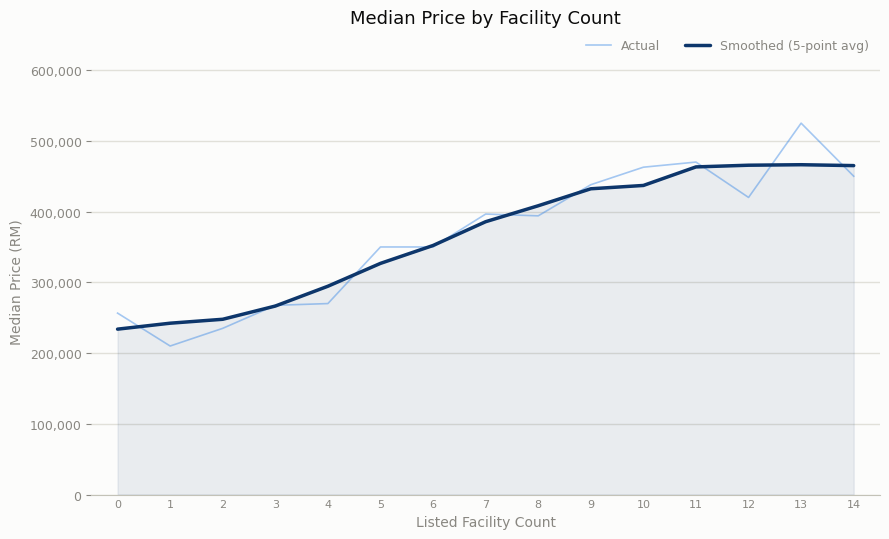

In [17]:
print("\n" + "=" * 60)
print("STEP 4.4.3: FACILITY COUNT PATTERN")
print("=" * 60)

facility_trend = df.groupby('Listed_Facility_Count', observed=True)['price'].agg(
    Count='count', Median_Price='median')
print("\n--- Median Price by Facility Count (every count) ---")
print(facility_trend)

plot_ordinal_line_trend(
    labels=[str(int(c)) for c in facility_trend.index],
    values=facility_trend['Median_Price'].tolist(),
    title="Median Price by Facility Count",
    xlabel="Listed Facility Count",
    ylabel="Median Price (RM)",
    filename="fig_443_price_by_facility_tier.png",
)


## 4.4.4 Price vs Property Size Anomalies

Flags the 10 listings whose price deviates most from the 4.3.2 size-based trend.


STEP 4.4.4: PRICE VS PROPERTY SIZE ANOMALIES

--- Top 10 Price-vs-Size Anomalies (largest |actual - predicted|) ---
 Property Size  Bedroom  Bathroom   price  Predicted_Price      Residual
        9376.0        4         2  250000     4.550637e+06 -4.300637e+06
        6016.0        5         7 6016000     2.892027e+06  3.123973e+06
        3878.0        4         4 3600000     1.836639e+06  1.763361e+06
        6800.0        6         5 5000000     3.279036e+06  1.720964e+06
        1406.0        3         3 2300000     6.163760e+05  1.683624e+06
        1636.0        3         4 2200000     7.299118e+05  1.470088e+06
        1853.0        4         6 2300000     8.370303e+05  1.462970e+06
        3072.0        3         5 2800000     1.438770e+06  1.361230e+06
        4500.0        3         3 3499999     2.143679e+06  1.356320e+06
        3900.0        5         4 3200000     1.847499e+06  1.352501e+06



Saved: fig_444_price_size_anomalies.png

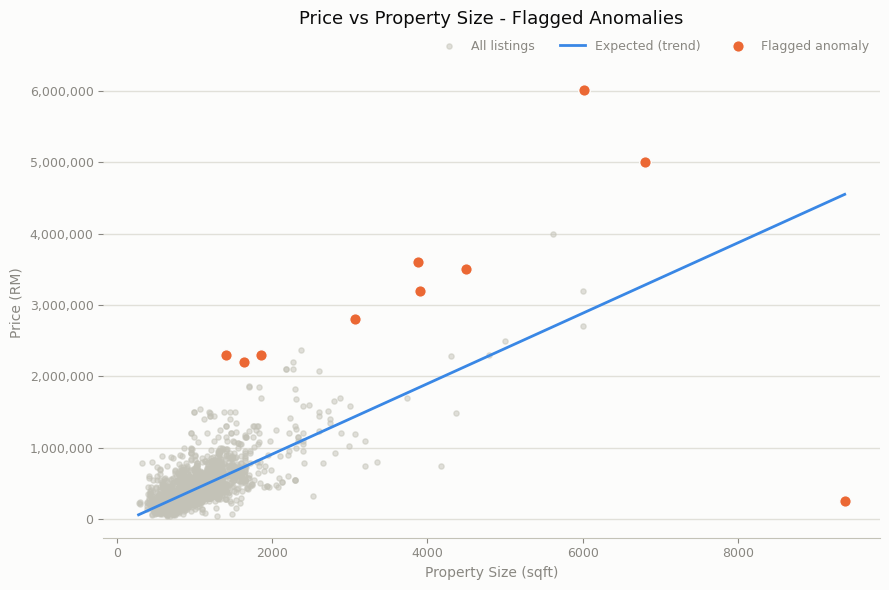

In [18]:
print("\n" + "=" * 60)
print("STEP 4.4.4: PRICE VS PROPERTY SIZE ANOMALIES")
print("=" * 60)

# Reuses the linear fit (slope, intercept) from 4.3.2. A listing far from
# that line is priced very differently than its size would predict -
# a bivariate anomaly, not the single-variable outliers already handled
# in Sections 3.6/3.7.
size_df = df.dropna(subset=['Property Size']).copy()
size_df['Predicted_Price'] = slope * size_df['Property Size'] + intercept
size_df['Residual'] = size_df['price'] - size_df['Predicted_Price']

is_anomaly_size = size_df['Residual'].abs().rank(ascending=False, method='first') <= 10
top_anomalies_size = size_df.loc[is_anomaly_size,
    ['Property Size', 'Bedroom', 'Bathroom', 'price', 'Predicted_Price', 'Residual']
].sort_values('Residual', key=abs, ascending=False)
print("\n--- Top 10 Price-vs-Size Anomalies (largest |actual - predicted|) ---")
print(top_anomalies_size.to_string(index=False))

fit_x = np.linspace(size_df['Property Size'].min(), size_df['Property Size'].max(), 100)
fit_y = slope * fit_x + intercept

plot_emphasis_scatter(
    data=size_df, x_col='Property Size', y_col='price', is_anomaly=is_anomaly_size,
    line_x=fit_x, line_y=fit_y,
    xlabel="Property Size (sqft)", ylabel="Price (RM)",
    title="Price vs Property Size - Flagged Anomalies",
    filename="fig_444_price_size_anomalies.png",
)


## 4.4.5 Facility Tier Deviation Anomalies

Flags the 10 listings whose price deviates most from their own facility-count tier's median.


STEP 4.4.5: FACILITY TIER DEVIATION ANOMALIES

--- Top 10 Facility-Tier Anomalies (largest |actual - tier median|) ---
 Listed_Facility_Count   price  Facility_Expected_Price  Facility_Residual
                    11 6016000                 470000.0          5546000.0
                     7 5000000                 396500.0          4603500.0
                    13 4000000                 525000.0          3475000.0
                     0 3499999                 256500.0          3243499.0
                    11 3600000                 470000.0          3130000.0
                     9 3200000                 438000.0          2762000.0
                    14 3200000                 450000.0          2750000.0
                     3 2700000                 267500.0          2432500.0
                     9 2800000                 438000.0          2362000.0
                    13 2500000                 525000.0          1975000.0



Saved: fig_445_facility_anomalies.png


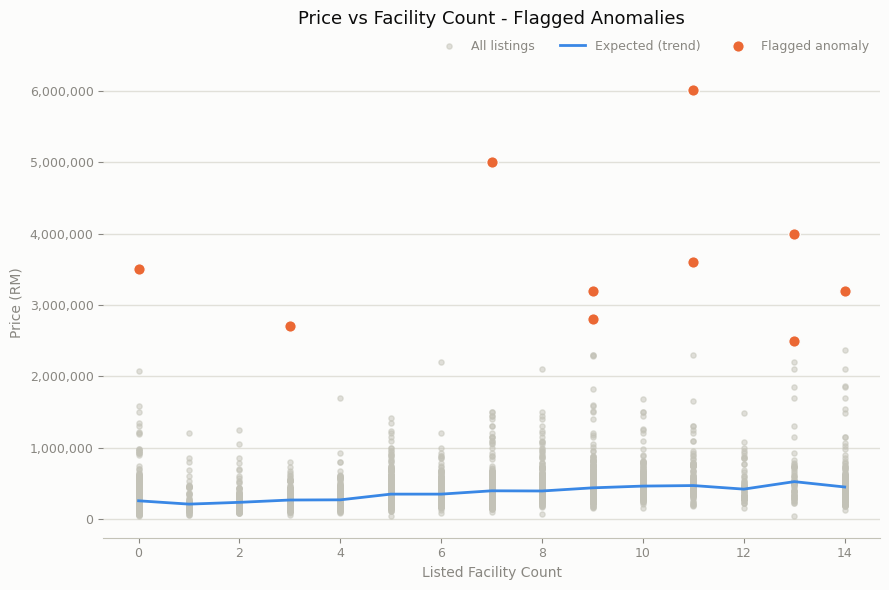

In [19]:
print("\n" + "=" * 60)
print("STEP 4.4.5: FACILITY TIER DEVIATION ANOMALIES")
print("=" * 60)

# Expected price = the 4.4.3 median for that listing's own facility count.
# A listing far from its own tier's median is anomalous relative to what
# similar-facility listings sell for.
df['Facility_Expected_Price'] = df['Listed_Facility_Count'].map(facility_trend['Median_Price'])
df['Facility_Residual'] = df['price'] - df['Facility_Expected_Price']

is_anomaly_fac = df['Facility_Residual'].abs().rank(ascending=False, method='first') <= 10
top_anomalies_fac = df.loc[is_anomaly_fac,
    ['Listed_Facility_Count', 'price', 'Facility_Expected_Price', 'Facility_Residual']
].sort_values('Facility_Residual', key=abs, ascending=False)
print("\n--- Top 10 Facility-Tier Anomalies (largest |actual - tier median|) ---")
print(top_anomalies_fac.to_string(index=False))

plot_emphasis_scatter(
    data=df, x_col='Listed_Facility_Count', y_col='price', is_anomaly=is_anomaly_fac,
    line_x=facility_trend.index.tolist(), line_y=facility_trend['Median_Price'].tolist(),
    xlabel="Listed Facility Count", ylabel="Price (RM)",
    title="Price vs Facility Count - Flagged Anomalies",
    filename="fig_445_facility_anomalies.png",
)


## 4.4.6 Property Age Deviation Anomalies

Flags the 10 listings whose price deviates most from their own property-age median.


STEP 4.4.6: PROPERTY AGE DEVIATION ANOMALIES

--- Top 10 Property-Age Anomalies (largest |actual - age median|) ---
 Property Age   price  Age_Expected_Price  Age_Residual
          6.0 4000000            500000.0     3500000.0
          7.0 3600000            480000.0     3120000.0
         16.0 3499999            380000.0     3119999.0
         14.0 3200000            330000.0     2870000.0
         10.0 2800000            460000.0     2340000.0
         11.0 2500000            389000.0     2111000.0
         14.0 2368000            330000.0     2038000.0
         10.0 2300000            460000.0     1840000.0
          6.0 2300000            500000.0     1800000.0
         12.0 2280000            557500.0     1722500.0


C:\Users\Low\AppData\Local\Temp\ipykernel_81280\805124179.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  flagged = data[is_anomaly]



Saved: fig_446_property_age_anomalies.png

All of Section 4.4 complete.


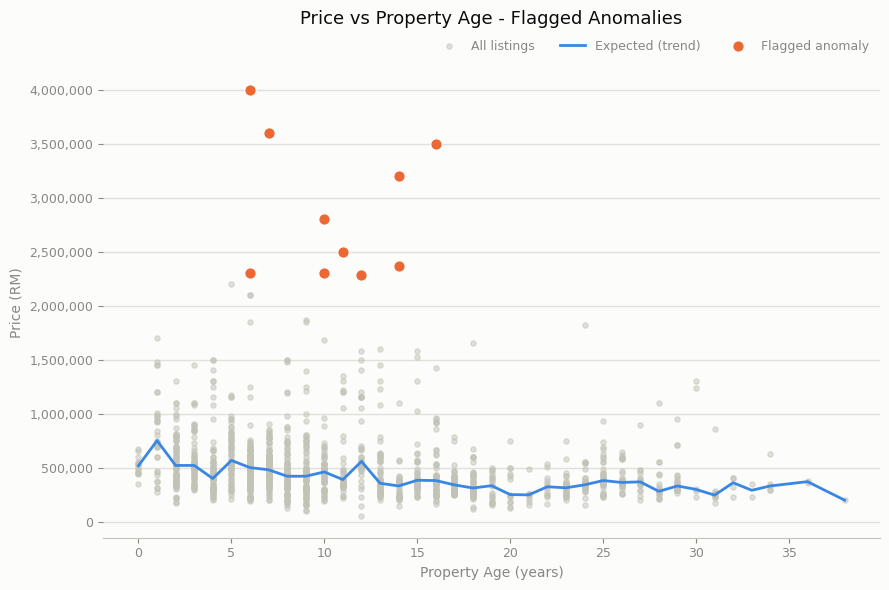

In [20]:
print("\n" + "=" * 60)
print("STEP 4.4.6: PROPERTY AGE DEVIATION ANOMALIES")
print("=" * 60)

# Expected price = the 4.4.2 median for that listing's own property age.
df['Age_Expected_Price'] = df['Property Age'].map(age_trend['Median_Price'])
df['Age_Residual'] = df['price'] - df['Age_Expected_Price']

is_anomaly_age = df['Age_Residual'].abs().rank(ascending=False, method='first') <= 10
top_anomalies_age = df.loc[is_anomaly_age,
    ['Property Age', 'price', 'Age_Expected_Price', 'Age_Residual']
].sort_values('Age_Residual', key=abs, ascending=False)
print("\n--- Top 10 Property-Age Anomalies (largest |actual - age median|) ---")
print(top_anomalies_age.to_string(index=False))

plot_emphasis_scatter(
    data=df.dropna(subset=['Property Age']), x_col='Property Age', y_col='price', is_anomaly=is_anomaly_age,
    line_x=age_trend.index.tolist(), line_y=age_trend['Median_Price'].tolist(),
    xlabel="Property Age (years)", ylabel="Price (RM)",
    title="Price vs Property Age - Flagged Anomalies",
    filename="fig_446_property_age_anomalies.png",
)

print(f"\nAll of Section 4.4 complete.")


## 4.5.1 Summary of Key Analytical Findings


In [21]:
print("\n" + "=" * 60)
print("STEP 4.5.1: SUMMARY OF KEY ANALYTICAL FINDINGS")
print("=" * 60)

top_numeric = core_corr_vs_price.reindex(core_corr_vs_price.abs().sort_values(ascending=False).index)
top_amenity = amenity_corr.reindex(amenity_corr.abs().sort_values(ascending=False).index)
type_spread = summary["Median"].max() - summary["Median"].min()

print("\n--- Core numeric features ranked by |r| with log10_price (top 5) ---")
print(top_numeric.head(5))
print("\n--- Amenity flags ranked by |r| with log10_price (top 3) ---")
print(top_amenity.head(3))
print("\nProperty Type median-price range: RM {:,.0f} ({}) to RM {:,.0f} ({}) -> spread of RM {:,.0f}".format(
    summary["Median"].min(), summary["Median"].idxmin(),
    summary["Median"].max(), summary["Median"].idxmax(), type_spread))
print("\nProperty Age effect: median price falls from RM{:,.0f} at age 0 to a ~RM300k-350k plateau by ~age 20 (Section 4.4.2)".format(
    age_trend["Median_Price"].iloc[0]))



STEP 4.5.1: SUMMARY OF KEY ANALYTICAL FINDINGS

--- Core numeric features ranked by |r| with log10_price (top 5) ---
Property Size            0.616801
Bathroom                 0.524114
Parking Lot              0.521192
Listed_Facility_Count    0.442522
# of Floors              0.438424
Name: log10_price, dtype: float64

--- Amenity flags ranked by |r| with log10_price (top 3) ---
Has_Gymnasium        0.493350
Has_Swimming_Pool    0.468872
Has_Security         0.369551
Name: log10_price, dtype: float64

Property Type median-price range: RM 155,000 (Flat) to RM 470,000 (Condominium) -> spread of RM 315,000

Property Age effect: median price falls from RM518,000 at age 0 to a ~RM300k-350k plateau by ~age 20 (Section 4.4.2)


## 4.5.2 Implications for Feature Importance


In [22]:
print("\n" + "=" * 60)
print("STEP 4.5.2: RANKED FEATURE-IMPORTANCE EXPECTATION")
print("=" * 60)

combined_corr = pd.concat([core_corr_vs_price, amenity_corr])
ranked_importance = combined_corr.reindex(combined_corr.abs().sort_values(ascending=False).index)
ranked_importance = ranked_importance.to_frame("corr_with_log10_price")
ranked_importance.insert(0, "Rank", range(1, len(ranked_importance) + 1))

print("\n--- Ranked feature-importance expectation (by |r| with log10_price) ---")
print(ranked_importance.head(10).to_string())



STEP 4.5.2: RANKED FEATURE-IMPORTANCE EXPECTATION

--- Ranked feature-importance expectation (by |r| with log10_price) ---
                       Rank  corr_with_log10_price
Property Size             1               0.616801
Bathroom                  2               0.524114
Parking Lot               3               0.521192
Has_Gymnasium             4               0.493350
Has_Swimming_Pool         5               0.468872
Listed_Facility_Count     6               0.442522
# of Floors               7               0.438424
Has_Security              8               0.369551
Has_Sauna                 9               0.354530
Has_Barbeque_Area        10               0.339510


## 4.5.3 Recommendations for Model Selection


In [23]:
print("\n" + "=" * 60)
print("STEP 4.5.3: EVIDENCE FOR MODEL-SELECTION RECOMMENDATIONS")
print("=" * 60)

skew_evidence = pd.DataFrame({
    "Variable": ["price (raw)", "log10(price)", "Property Size (raw)", "log(Property Size + 1)"],
    "Skewness": [skew_raw, skew_log, stats.skew(size), stats.skew(log_size)]
})
print("\n--- Skewness before/after transformation (linear-model transform evidence) ---")
print(skew_evidence.to_string(index=False))

multicollinearity_evidence = df[["Property Size", "Bathroom", "Bedroom"]].corr()
print("\n--- Multicollinearity among size-related features (Ridge-over-Linear evidence) ---")
print(multicollinearity_evidence.round(2))

print("\nNon-linear age effect: median price RM{:,.0f} at age 0 -> plateaus ~RM300k-350k by age 20+ (Section 4.4.2, fig_4_4_2)".format(
    age_trend["Median_Price"].iloc[0]))
print("Non-linear facility effect: median price RM{:,.0f} at 0 facilities -> plateaus ~RM450k-470k past 10 facilities (Section 4.4.3, fig_4_4_3)".format(
    facility_trend["Median_Price"].iloc[0]))



STEP 4.5.3: EVIDENCE FOR MODEL-SELECTION RECOMMENDATIONS

--- Skewness before/after transformation (linear-model transform evidence) ---
              Variable  Skewness
           price (raw)  5.633438
          log10(price)  0.228588
   Property Size (raw)  5.879364
log(Property Size + 1)  0.879166

--- Multicollinearity among size-related features (Ridge-over-Linear evidence) ---
               Property Size  Bathroom  Bedroom
Property Size           1.00      0.69     0.54
Bathroom                0.69      1.00     0.65
Bedroom                 0.54      0.65     1.00

Non-linear age effect: median price RM518,000 at age 0 -> plateaus ~RM300k-350k by age 20+ (Section 4.4.2, fig_4_4_2)
Non-linear facility effect: median price RM256,500 at 0 facilities -> plateaus ~RM450k-470k past 10 facilities (Section 4.4.3, fig_4_4_3)
